# Упражнение 4.7. Итерация по стратегиям: аренда машин Джека с модификациями

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 4 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch04.pdf).


In [3]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

In [4]:
# ───────────────── Константы ─────────────────
MAX_AUTO = 20
MAX_MOVE = 5

QUERY_MU_1 = 3
QUERY_MU_2 = 4
RETURN_MU_1 = 3
RETURN_MU_2 = 2

GAMMA = 0.9
THETA = 1e-15

N = MAX_AUTO + 1 # Для удобного использования в циклах

## Решение исходной задачи

In [5]:
V = np.zeros((N, N))
pi = np.zeros((N, N), dtype=int)

# ───────────────── Вычисление вероятностей ─────────────────
def poisson_probs(mu):
    """
    Используется для предподсчета вероятностей реализации случайных величин.
    Добавляется слагаемое к последнему элементу, чтобы обрезать пуассоновское распределение.
    """
    probs = poisson.pmf(np.arange(N), mu) # P(X=k), k=0,...,N-1
    probs[-1] += poisson.sf(N-1, mu)   # probs[N-1] = P(X=N-1) + P(X>=N) = P(X>=N-1)
    return probs

pQ1 = poisson_probs(QUERY_MU_1)  # Вероятности запросов в первом офисе
pQ2 = poisson_probs(QUERY_MU_2)  # Вероятности запросов во втором офисе
pR1 = poisson_probs(RETURN_MU_1) # Вероятности возвратов в первом офисе
pR2 = poisson_probs(RETURN_MU_2) # Вероятности возвратов во втором офисе

# ───────────────── ШАГ 1: предподсчет мат ожидания по возвратам ─────────────────
def compute_G(V):
    """
    G(b1, b2) = ...
    (b1, b2) - состояние среды после запросов
    """
    G = np.zeros_like(V)
    for b1 in range(N):
        for b2 in range(N):
            val = 0.0
            for r1 in range(N):
                for r2 in range(N):
                    s1 = min(b1 + r1, MAX_AUTO)
                    s2 = min(b2 + r2, MAX_AUTO)
                    val += (
                        pR1[r1] *
                        pR2[r2] *
                        V[s1, s2]
                    )
            G[b1, b2] = val
    return G


# ───────────────── ШАГ 2: предподсчет мат ожидания по запросам ─────────────────
def expected_return(s1a, s2a, G, a):
    """
    V(s1, s2) = ...
    (s1, s2) - состояние среды перед запросом(после перегона)
    (q1, q2) - запросы в офисах
    (b1, b2) - состояние среды после запросов
    """
    val = 0.0
    for q1 in range(N):
        for q2 in range(N):
            rent1 = min(q1, s1a)
            rent2 = min(q2, s2a)
            b1 = s1a - rent1
            b2 = s2a - rent2
            reward = -2 * abs(a) + 10 * (rent1 + rent2)
            val += (
                pQ1[q1] *
                pQ2[q2] *
                (reward + GAMMA * G[b1, b2])
            )
    return val


# ───────────────── АЛГОРИТМ ─────────────────

policy_stable = False
iteration = 1

while not policy_stable:
    print("Iteration:", iteration)
    
    # ========= Оценивание политики =========
    while True:
        delta = 0
        G = compute_G(V)  
        
        for s1 in range(N):
            for s2 in range(N):
                v_old = V[s1, s2]
                a = pi[s1, s2]
                s1a = s1 - a
                s2a = s2 + a
                V[s1, s2] = expected_return(
                    s1a, s2a, G, a
                )
                delta = max(delta, abs(v_old - V[s1, s2]))

        if delta < THETA:
            break
            
    # ========= Улучшение политики =========
    policy_stable = True

    for s1 in range(N):
        for s2 in range(N):
            old_action = pi[s1, s2]
            best_value = -1e18
            best_action = old_action

            for a in range(
                -min(min(MAX_MOVE, s2), MAX_AUTO-s1),
                 min(min(MAX_MOVE, s1), MAX_AUTO-s2) + 1
            ):
                s1a = s1 - a
                s2a = s2 + a
                val = expected_return(
                    s1a, s2a, G, a
                )
                if val > best_value:
                    best_value = val
                    best_action = a
                    
            pi[s1, s2] = best_action

            if best_action != old_action:
                policy_stable = False

    iteration += 1

print("FINISHED")

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
FINISHED


In [6]:
pi

array([[ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -2, -2, -2, -3, -3, -3,
        -3, -3, -4, -4, -4],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -2, -2, -2, -2,
        -2, -3, -3, -3, -3],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1,
        -2, -2, -2, -2, -2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        -1, -1, -1, -1, -2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0, -1, -1],
       [ 1,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0],
       [ 2,  2,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0],
       [ 3,  2,  2,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0],
       [ 3,  3,  2,  2,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0],
       [ 4,  3,  3,  2,  2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,

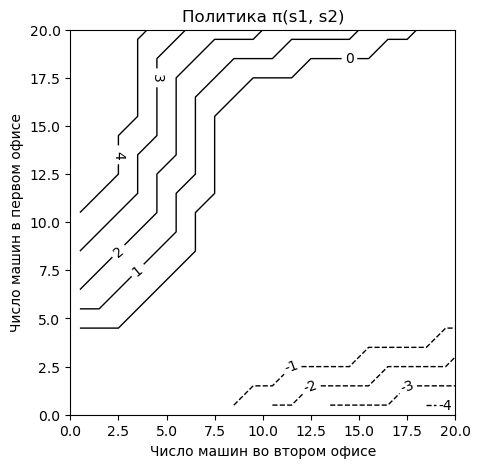

In [7]:
pi = np.asarray(pi)

actions = np.sort(np.unique(pi))          # реальные дискретные действия
levels = actions.astype(float)            # контуры именно по значениям

plt.figure(figsize=(6, 5))
cs = plt.contour(
    pi,
    levels=levels,
    colors="k",
    linewidths=1,
    origin="lower"
)

# подписываем тем же набором levels -> подписи будут 1 к 1
plt.clabel(cs, fmt={float(a): str(int(a)) for a in actions}, inline=True, fontsize=10)

plt.xlabel("Число машин во втором офисе")
plt.ylabel("Число машин в первом офисе")
plt.xlim(0, pi.shape[1]-1)
plt.ylim(0, pi.shape[0]-1)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Политика π(s1, s2)")
plt.show()

## Решение задачи 4.7

In [ ]:
V = np.zeros((N, N))
pi = np.zeros((N, N), dtype=int)

# ───────────────── Вычисление вероятностей ─────────────────
def poisson_probs(mu):
    """
    Используется для предподсчета вероятностей реализации случайных величин.
    Добавляется слагаемое к последнему элементу, чтобы обрезать пуассоновское распределение.
    """
    probs = poisson.pmf(np.arange(N), mu) # P(X=k), k=0,...,N-1
    probs[-1] += poisson.sf(N-1, mu)   # probs[N-1] = P(X=N-1) + P(X>=N) = P(X>=N-1)
    return probs

pQ1 = poisson_probs(QUERY_MU_1)  # Вероятности запросов в первом офисе
pQ2 = poisson_probs(QUERY_MU_2)  # Вероятности запросов во втором офисе
pR1 = poisson_probs(RETURN_MU_1) # Вероятности возвратов в первом офисе
pR2 = poisson_probs(RETURN_MU_2) # Вероятности возвратов во втором офисе

# ───────────────── ШАГ 1: предподсчет мат ожидания по возвратам ─────────────────
def compute_G(V):
    """
    G(b1, b2) = ...
    (b1, b2) - состояние среды после запросов
    """
    G = np.zeros_like(V)
    for b1 in range(N):
        for b2 in range(N):
            val = 0.0
            for r1 in range(N):
                for r2 in range(N):
                    s1 = min(b1 + r1, MAX_AUTO)
                    s2 = min(b2 + r2, MAX_AUTO)
                    val += (
                        pR1[r1] *
                        pR2[r2] *
                        V[s1, s2]
                    )
            G[b1, b2] = val
    return G


# ───────────────── ШАГ 2: предподсчет мат ожидания по запросам ─────────────────
def expected_return(s1a, s2a, G, a):
    """
    V(s1a, s2a) = ...
    (s1a, s2a) - состояние среды перед запросом(после перегона)
    (q1, q2) - запросы в офисах
    (b1, b2) - состояние среды после запросов
    """
    val = 0.0
    # ───────────────── МОДИФИКАЦИЯ ─────────────────
    if a > 0:
        move_cost = 2 * (a - 1)
    else:
        move_cost = 2 * abs(a)
        
    sub = 0
    if s1a > 10:
        sub += 4
    if s2a > 10:
        sub += 4
    # ───────────────────────────────────────────────
    for q1 in range(N):
        for q2 in range(N):
            rent1 = min(q1, s1a)
            rent2 = min(q2, s2a)
            b1 = s1a - rent1
            b2 = s2a - rent2
            reward = 10*(rent1+rent2) - sub - move_cost # Изменил под новые условия
            val += (
                pQ1[q1] *
                pQ2[q2] *
                (reward + GAMMA * G[b1, b2])
            )
    return val


# ───────────────── АЛГОРИТМ ─────────────────

policy_stable = False
iteration = 1

while not policy_stable:
    print("Iteration:", iteration)
    
    # ========= Оценивание политики =========
    while True:
        delta = 0
        G = compute_G(V)  
        
        for s1 in range(N):
            for s2 in range(N):
                v_old = V[s1, s2]
                a = pi[s1, s2]
                s1a = s1 - a
                s2a = s2 + a
                V[s1, s2] = expected_return(
                    s1a, s2a, G, a
                )
                delta = max(delta, abs(v_old - V[s1, s2]))

        if delta < THETA:
            break
            
    # ========= Улучшение политики =========
    policy_stable = True

    for s1 in range(N):
        for s2 in range(N):
            old_action = pi[s1, s2]
            best_value = -1e18
            best_action = old_action

            for a in range(
                -min(min(MAX_MOVE, s2), MAX_AUTO-s1),
                 min(min(MAX_MOVE, s1), MAX_AUTO-s2) + 1
            ):
                s1a = s1 - a
                s2a = s2 + a
                val = expected_return(
                    s1a, s2a, G, a
                )
                if val > best_value or (val == best_value and a < best_action):
                    best_value = val
                    best_action = a
                    
            pi[s1, s2] = best_action

            if best_action != old_action:
                policy_stable = False

    iteration += 1

print("FINISHED")

Iteration: 1


In [9]:
pi

array([[ 0,  0,  0,  0,  0,  0,  0, -1, -1, -2, -2, -3, -3, -3, -4, -5,
        -4, -4, -5, -5, -5],
       [ 1,  0,  0,  0,  0,  0,  0,  0, -1, -1, -2, -2, -2, -3, -4, -5,
        -3, -4, -4, -4, -4],
       [ 1,  1,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -2, -3, -4, -5,
        -3, -3, -3, -3, -3],
       [ 1,  1,  1,  1,  0,  0,  0,  0,  0,  0,  0, -1, -2, -3, -4, -5,
        -2, -2, -2, -2, -2],
       [ 1,  1,  1,  1,  1,  0,  0,  0,  0,  0,  0, -1, -2, -3, -4, -1,
        -1, -1, -1, -1, -1],
       [ 1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  0, -1, -2, -3,  0,  0,
         0,  0,  0,  0, -1],
       [ 2,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0, -1, -2,  0,  0,  0,
         0,  0,  0,  0,  0],
       [ 2,  2,  1,  1,  1,  1,  1,  1,  1,  0,  0, -1, -2,  0,  0,  0,
         0,  0,  0,  0,  0],
       [ 3,  2,  2,  1,  1,  1,  1,  1,  1,  1,  0, -1,  0,  0,  0,  0,
         0,  0,  0,  0,  0],
       [ 3,  3,  2,  2,  1,  1,  1,  1,  1,  1,  0, -1,  0,  0,  0,  0,
         0,  0,  0,

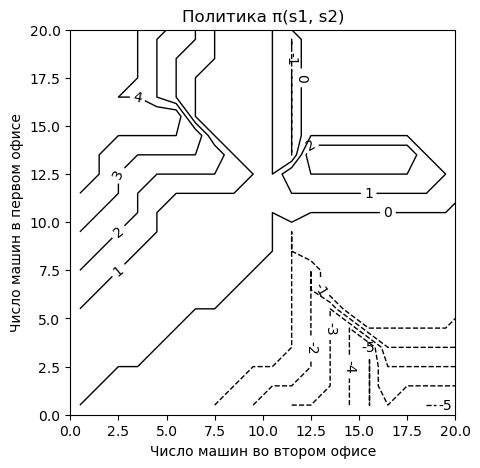

In [10]:
pi = np.asarray(pi)

actions = np.sort(np.unique(pi))          # реальные дискретные действия
levels = actions.astype(float)            # контуры именно по значениям

plt.figure(figsize=(6, 5))
cs = plt.contour(
    pi,
    levels=levels,
    colors="k",
    linewidths=1,
    origin="lower"
)

# подписываем тем же набором levels -> подписи будут 1 к 1
plt.clabel(cs, fmt={float(a): str(int(a)) for a in actions}, inline=True, fontsize=10)

plt.xlabel("Число машин во втором офисе")
plt.ylabel("Число машин в первом офисе")
plt.xlim(0, pi.shape[1]-1)
plt.ylim(0, pi.shape[0]-1)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Политика π(s1, s2)")
plt.show()